# 1. Introducción y Objetivos

### **Objetivo del Proyecto**
El objetivo es construir un modelo de clasificación que prediga la **especie** de una muestra basándose en sus características.

### **Justificación del Proyecto**
El dataset contiene una variable objetivo llamada **"Especie"**, que representa las clases que queremos predecir. Esta clasificación es importante porque:
1. Nos permite categorizar cada observación en una de las **83 clases disponibles**.
2. Representa un desafío debido al fuerte desbalance entre las clases, con algunas clases representadas por muchas muestras y otras por muy pocas.

Dado este contexto, las estrategias que seguiremos son:
- Utilizar un modelo robusto para datos desbalanceados como **Random Forest**.
- Evaluar el rendimiento del modelo utilizando el **Macro F1 Score**, que trata todas las clases por igual.
- Explorar técnicas como el **sobremuestreo** para mitigar el desbalance de clases.


# 2. Importación de Librerías y Carga de Datos

In [1]:
# Importar bibliotecas necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


In [2]:
# Cargar el archivo desde Colab (sube el archivo cuando se ejecute esta celda)
from google.colab import files
uploaded = files.upload()


Saving caracteristicas_papa_nativa_atributos (1).csv to caracteristicas_papa_nativa_atributos (1).csv


In [3]:

# Leer el archivo cargado (ajusta el nombre del archivo si es necesario)
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Inspeccionar los datos
print("Primeras filas del dataset:")
print(df.head())


Primeras filas del dataset:
       area    perimetro  aspect_ratio    extent  circularidad  hu_moment_1  \
0  141194.0  1692.989018      0.531100  0.676246      0.619039     0.705611   
1  132267.5  1630.947388      0.529605  0.675606      0.624861     0.704847   
2  128017.5  1623.148400      0.519135  0.682716      0.610608     0.699298   
3  146324.0  1693.332164      1.852941  0.683119      0.641270     0.713629   
4  139652.5  1666.805252      1.891239  0.673979      0.631668     0.692288   

   hu_moment_2  hu_moment_3  hu_moment_4  hu_moment_5  ...  haralick_10  \
0     1.934432     3.193659     3.920413     7.493589  ...     0.003873   
1     1.928899     3.195742     3.918714     7.491978  ...     0.003814   
2     1.900166     3.135597     3.837784     7.340955  ...     0.003643   
3     1.969772     3.331962     4.099396     7.828307  ...     0.003388   
4     1.855220     3.138292     3.798235     7.285708  ...     0.003313   

   haralick_11  haralick_12  haralick_13  colo

### **Importancia del Análisis de la Variable Objetivo**
El análisis de la variable objetivo **"Especie"** nos permite:
1. Detectar el desbalance de clases, que puede afectar el rendimiento del modelo, ya que tiende a favorecer las clases mayoritarias.
2. Decidir si es necesario aplicar técnicas para equilibrar el dataset, como el sobremuestreo (SMOTE).

En este caso, se observa un desbalance significativo, con clases como **15** teniendo muchas muestras y otras como **80** teniendo muy pocas.


In [4]:

# Separar características (X) y etiquetas (y)
# Cambia 'Especie' si la columna de etiquetas tiene otro nombre
X = df.drop(columns=['etiqueta'])
y = df['etiqueta']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




### **Justificación**
Dividir los datos en **entrenamiento (80%)** y **prueba (20%)** es crucial porque:
1. **Entrenamiento:** Permite que el modelo aprenda patrones de los datos.
2. **Prueba:** Nos proporciona un conjunto separado para evaluar el desempeño del modelo en datos no vistos.

El uso del parámetro `stratify=y` asegura que la distribución de las clases en ambos conjuntos sea similar a la del dataset original.


### **¿Por qué Random Forest?**
1. Es un modelo robusto que combina múltiples árboles de decisión para mejorar la precisión y reducir el sobreajuste.
2. Puede manejar datasets desbalanceados y clasificaciones multiclase eficientemente.
3. Es fácil de interpretar, ya que ofrece métricas como la importancia de características.


### **¿Por qué usar el Macro F1 Score?**
El **Macro F1 Score** es ideal para este problema porque:
1. Calcula el F1 Score para cada clase y luego promedia los valores, **dando igual peso a todas las clases**.
2. Es útil en datasets desbalanceados, ya que no favorece a las clases mayoritarias.


In [ ]:
# Asegurarse de que las columnas sean numéricas
# Elimina columnas irrelevantes como identificadores de imágenes
X = df.drop(columns=['etiqueta', 'nombre_imagen'], errors='ignore')  # Cambia 'Imagen_ID' si tiene otro nombre
y = df['etiqueta']

# Verificar y convertir columnas no numéricas (si las hay)
X = X.apply(pd.to_numeric, errors='coerce')  # Convierte datos a numérico, llenando NaN en no convertibles
X = X.fillna(0)  # Reemplaza NaN con 0 o usa otra estrategia si es necesario

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular el Macro F1 Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())


Especie
15    127
14    116
81     76
59     75
28     64
     ... 
30     34
78     23
79     21
77     20
80     20
Name: count, Length: 83, dtype: int64
Especie
15    39
81    22
68    21
12    21
14    21
      ..
54     6
78     5
80     5
21     5
7      5
Name: count, Length: 83, dtype: int64


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
print(f"Macro F1 Score promedio en validación cruzada: {scores.mean():.4f}")


Macro F1 Score promedio en validación cruzada: 0.8727


### **¿Por qué analizar las características importantes?**
La **importancia de las características** nos dice cuáles atributos tienen más peso en la predicción de las clases. Esto ayuda a:
1. Entender cómo el modelo toma decisiones.
2. Optimizar futuros modelos, eliminando características poco relevantes.


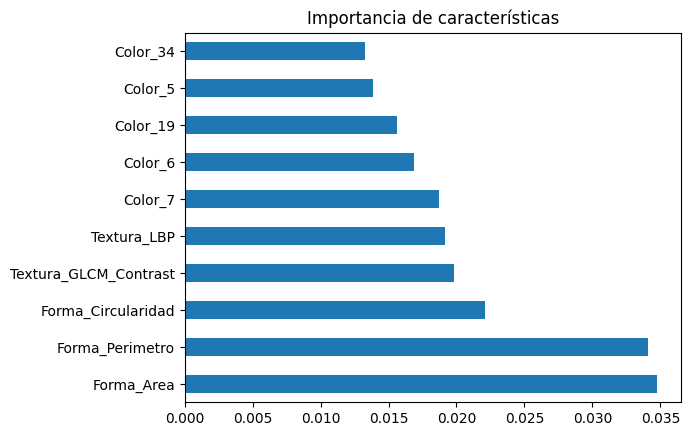

In [ ]:
import matplotlib.pyplot as plt
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Importancia de características")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      0.83      0.91        12
           2       0.75      1.00      0.86         9
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        10
           5       0.86      0.60      0.71        10
           6       0.75      0.86      0.80         7
           7       0.80      0.80      0.80         5
           8       0.90      0.75      0.82        12
           9       1.00      1.00      1.00        12
          10       0.89      0.89      0.89        19
          11       1.00      1.00      1.00        12
          12       0.95      0.90      0.93        21
          13       1.00      1.00      1.00        15
          14       0.91      1.00      0.95        21
          15       1.00      1.00      1.00        39
          16       1.00      1.00      1.00        17
          17       1.00      1.00      1.00         8
          18       1.00    